<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Algorithmic Trading

**Chapter 10 &mdash; Stock Trading with Interactive Brokers**

## A Wrapper Class for the IB API

In [ ]:
!git clone https://github.com/tpq-classes/python_for_algo_trading_core.git
import sys
sys.path.append('python_for_algo_trading_core')


In [1]:
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

In [2]:
import logging
mpl_logger = logging.getLogger('matplotlib')
mpl_logger.setLevel(logging.WARNING)

In [3]:
import tpqib

In [4]:
con = tpqib.tpqibcon()

Server Version: 76
TWS Time at connection:20200724 15:21:28 CET


## Retrieving Historical Data

In [5]:
fx_contract = con.create_fx('EUR', 'IDEALPRO', 'USD')

In [6]:
con.contract_details(fx_contract).T

,0
bondType,
callable,False
category,None
contractMonth,None
convertible,False
coupon,0
couponType,
cusip,
descAppend,
evMultiplier,0


In [7]:
aapl_contract = con.create_stock('AAPL', 'SMART', 'USD')

In [8]:
con.contract_details(aapl_contract).T

,0
bondType,
callable,False
category,Computers
contractMonth,None
convertible,False
coupon,0
couponType,
cusip,
descAppend,
evMultiplier,0


In [10]:
print(con.current_market_data(fx_contract))

Server Response: marketDataType, <marketDataType reqId=80, marketDataType=1>
   bidPrice  bidSize  askPrice  askSize  halted    high      low   close
0     1.161  2000000     1.161  2000000     0.0  1.1622  1.15815  1.1597


In [11]:
import datetime as dt

In [12]:
end_date = dt.datetime.now()

In [13]:
end_date

datetime.datetime(2020, 7, 24, 15, 25, 20, 340411)

In [14]:
request_id = con.request_historical_data(
                fx_contract, end_date,
                '1 D', '8 hours', 'MIDPOINT')

In [15]:
request_id

81

In [16]:
print(con.get_historical_data(request_id))

                         open      high       low     close  volume  count  \
date                                                                         
2020-07-23 23:15:00  1.159575  1.160275  1.159225  1.159545      -1     -1   
2020-07-24 02:00:00  1.159545  1.162145  1.159015  1.161020      -1     -1   
2020-07-24 10:00:00  1.161020  1.162195  1.158125  1.161520      -1     -1   

                     WAP  hasGaps  
date                               
2020-07-23 23:15:00 -1.0    False  
2020-07-24 02:00:00 -1.0    False  
2020-07-24 10:00:00 -1.0    False  


In [17]:
request_id = con.request_historical_data(
                fx_contract, end_date,
                '1 W', '5 mins', 'MIDPOINT')

In [18]:
request_id

82

In [19]:
data = con.get_historical_data(request_id)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1335 entries, 2020-07-19 23:15:00 to 2020-07-24 15:25:00
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   open     1335 non-null   float64
 1   high     1335 non-null   float64
 2   low      1335 non-null   float64
 3   close    1335 non-null   float64
 4   volume   1335 non-null   int64  
 5   count    1335 non-null   int64  
 6   WAP      1335 non-null   float64
 7   hasGaps  1335 non-null   bool   
dtypes: bool(1), float64(5), int64(2)
memory usage: 84.7 KB


In [21]:
print(data.tail(10))

                         open      high       low     close  volume  count  \
date                                                                         
2020-07-24 14:40:00  1.161235  1.161475  1.160920  1.160945      -1     -1   
2020-07-24 14:45:00  1.160945  1.161245  1.160665  1.161235      -1     -1   
2020-07-24 14:50:00  1.161235  1.161740  1.161230  1.161295      -1     -1   
2020-07-24 14:55:00  1.161295  1.161775  1.161245  1.161485      -1     -1   
2020-07-24 15:00:00  1.161485  1.162195  1.161385  1.161685      -1     -1   
2020-07-24 15:05:00  1.161685  1.161885  1.161085  1.161230      -1     -1   
2020-07-24 15:10:00  1.161230  1.161525  1.160895  1.160895      -1     -1   
2020-07-24 15:15:00  1.160895  1.161025  1.160565  1.160880      -1     -1   
2020-07-24 15:20:00  1.160880  1.161615  1.160875  1.161600      -1     -1   
2020-07-24 15:25:00  1.161600  1.161610  1.161505  1.161520      -1     -1   

                     WAP  hasGaps  
date                       

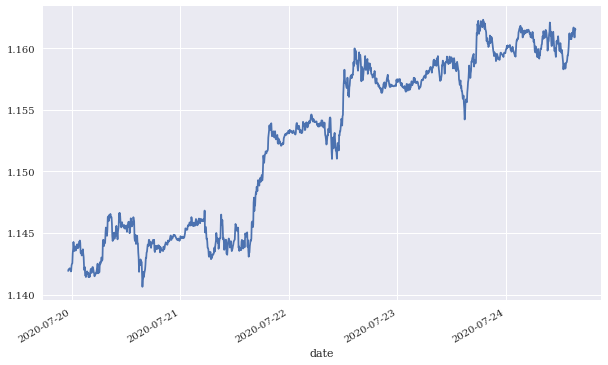

In [22]:
data['close'].plot(figsize=(10, 6));

In [23]:
tpqib.VALID_BAR_SIZES

['1 sec',
 '5 secs',
 '10 secs',
 '15 secs',
 '30 secs',
 '1 min',
 '2 mins',
 '3 mins',
 '5 mins',
 '10 mins',
 '15 mins',
 '20 mins',
 '30 mins',
 '1 hour',
 '2 hours',
 '3 hours',
 '4 hours',
 '8 hours',
 '1 day',
 '1 week',
 '1 month']

## Working with Streaming Data from the IB API

In [24]:
tpqib.STREAMING_DATA_TYPES

['lastTimestamp',
 'askPrice',
 'askSize',
 'bidPrice',
 'bidSize',
 'low',
 'high',
 'close',
 'volume',
 'lastPrice',
 'lastSize',
 'halted']

In [36]:
def print_bid_ask_price(field, value):
    if field == 'bidPrice':
        print(dt.datetime.now(), '| bid is %s' % value)
    if field == 'askPrice':
        print(dt.datetime.now(), '| ask is %s' % value)

In [37]:
request_id = con.request_market_data(fx_contract,
                                     print_bid_ask_price)

Server Response: marketDataType, <marketDataType reqId=87, marketDataType=1>
2020-07-24 15:40:18.883430 | bid is 1.16035
2020-07-24 15:40:18.884158 | ask is 1.16035
2020-07-24 15:40:18.885016 | bid is 1.16038
2020-07-24 15:40:18.885554 | ask is 1.1604
2020-07-24 15:40:19.436822 | ask is 1.16041
2020-07-24 15:40:19.550429 | bid is 1.1604
2020-07-24 15:40:19.755656 | ask is 1.16042
2020-07-24 15:40:19.871899 | bid is 1.16039
2020-07-24 15:40:19.872723 | ask is 1.1604
2020-07-24 15:40:20.000056 | ask is 1.16041
2020-07-24 15:40:20.344364 | bid is 1.16037
2020-07-24 15:40:20.345086 | ask is 1.16039
2020-07-24 15:40:20.445298 | bid is 1.16038
2020-07-24 15:40:20.445523 | ask is 1.1604


In [38]:
con.cancel_market_data(request_id)

## Implementing Trading Strategies in Real-Time

In [39]:
units = 20000

In [40]:
buy_order = con.create_order('MKT', units, 'BUY')

In [45]:
sell_order = con.create_order('MKT', units, 'SELL')

In [46]:
con.place_order(fx_contract, buy_order)

Order: BUY 20000 EUR
    Filled: 0, Status: Submitted
    Filled: 20000, Status: Filled
    Filled: 20000, Status: Filled


In [47]:
con.place_order(fx_contract, sell_order)

Order: SELL 20000 EUR
    Filled: 0, Status: Submitted
    Filled: 20000, Status: Filled
    Filled: 20000, Status: Filled


In [48]:
def SMA_strategy(field, value):
    global data
    global ticks
    global resam
    global position
    global request_id
    global min_length
    if field == 'bidPrice':
        ticks += 1
        timestamp = dt.datetime.now()
        data = data.append(pd.DataFrame({'bid': value},
                                        index=[timestamp]),
                          sort=True)
        if ticks % 10 == 0:
            print('%3d | ' % ticks, timestamp, '| bid is %s' % value)
    elif field == 'askPrice':
        ticks += 1
        timestamp = dt.datetime.now()
        data = data.append(pd.DataFrame({'ask': value},
                                        index=[timestamp]),
                          sort=True)
        if ticks % 10 == 0:
            print('%3d | ' % ticks, timestamp, '| ask is %s' % value)
    resam = data.resample('3s', label='right').last().ffill()
    if len(resam) >= min_length:
        min_length += 1
        resam['SMA1'] = resam.mean(axis=1).rolling(SMA1).mean()
        resam['SMA2'] = resam.mean(axis=1).rolling(SMA2).mean()
        resam['position'] = np.where(resam['SMA1'] > resam['SMA2'],
                                     1, -1)
        if resam['position'].iloc[-2] == 1 and position == 0: 
            con.place_order(fx_contract, buy_order)
            position = 1
        elif resam['position'].iloc[-2] == -1 and position == 1:
            con.place_order(fx_contract, sell_order)
            position = 0

In [49]:
import numpy as np
import pandas as pd

In [50]:
ticks = 0

In [51]:
position = 0

In [52]:
data = pd.DataFrame()

In [53]:
SMA1 = 5
SMA2 = 10

In [54]:
min_length = SMA2 + 1

In [55]:
request_id = con.request_market_data(fx_contract, SMA_strategy)

Server Response: marketDataType, <marketDataType reqId=92, marketDataType=1>
 10 |  2020-07-24 15:53:35.122536 | bid is 1.16146
 20 |  2020-07-24 15:53:40.372329 | bid is 1.16142
 30 |  2020-07-24 15:53:41.749536 | bid is 1.16136
 40 |  2020-07-24 15:53:42.742833 | bid is 1.16137
 50 |  2020-07-24 15:53:46.142988 | ask is 1.16134
 60 |  2020-07-24 15:53:47.340730 | ask is 1.16133
 70 |  2020-07-24 15:53:49.225515 | ask is 1.16136
 80 |  2020-07-24 15:53:50.101365 | ask is 1.16136
 90 |  2020-07-24 15:53:52.484811 | bid is 1.16135
100 |  2020-07-24 15:53:53.137183 | bid is 1.16136
110 |  2020-07-24 15:53:57.790647 | bid is 1.16133
120 |  2020-07-24 15:54:00.668772 | bid is 1.16135
130 |  2020-07-24 15:54:01.609120 | ask is 1.16144
140 |  2020-07-24 15:54:03.438517 | ask is 1.16144
150 |  2020-07-24 15:54:06.451984 | ask is 1.16148
Order: BUY 20000 EUR
    Filled: 0, Status: PreSubmitted
    Filled: 20000, Status: Filled
    Filled: 20000, Status: Filled
160 |  2020-07-24 15:54:11.088073

In [56]:
con.cancel_market_data(request_id)

In [57]:
data.tail()

,ask,bid
2020-07-24 15:54:57.454482,1.16167,NaN
2020-07-24 15:54:57.660118,NaN,1.16164
2020-07-24 15:54:57.669206,1.16165,NaN
2020-07-24 15:54:57.867833,NaN,1.16158
2020-07-24 15:54:57.876217,1.16159,NaN


In [60]:
resam.tail()

,ask,bid
2020-07-24 15:54:48,1.16158,1.16157
2020-07-24 15:54:51,1.16148,1.16147
2020-07-24 15:54:54,1.16160,1.16159
2020-07-24 15:54:57,1.16165,1.16164
2020-07-24 15:55:00,1.16159,1.16158


## Retrieving Account Information

In [61]:
symbols = ['EUR', 'GBP', 'AUD']

In [62]:
contracts = {sym: con.create_fx(sym, 'IDEALPRO', 'USD')
             for sym in symbols}

In [63]:
contracts

{'EUR': <ib.ext.Contract.Contract at 0x7ff3f8b9c310>,
 'GBP': <ib.ext.Contract.Contract at 0x7ff3f8b9c410>,
 'AUD': <ib.ext.Contract.Contract at 0x7ff3f8b9c490>}

In [64]:
buy_order = con.create_order('MKT', 50000, 'BUY')

In [65]:
for sym in symbols:
    con.place_order(contracts[sym], buy_order)

Order: BUY 50000 EUR
    Filled: 0, Status: Submitted
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled
Order: BUY 50000 GBP
    Filled: 0, Status: Submitted
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled
Order: BUY 50000 AUD
    Filled: 0, Status: PreSubmitted
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled


In [66]:
con.req_positions()

Quantity: 50000, Symbol: EUR, Currency: USD, Average Cost: 1.16127
Quantity: 1142, Symbol: ESGV, Currency: USD, Average Cost: 52.7765556
Quantity: 954, Symbol: ESGD, Currency: USD, Average Cost: 64.1715282
Quantity: 50000, Symbol: GBP, Currency: USD, Average Cost: 1.2766
Quantity: 292, Symbol: DVY, Currency: USD, Average Cost: 101.06176745
Quantity: 50, Symbol: VO, Currency: USD, Average Cost: 170.48881
Quantity: 99, Symbol: VDE, Currency: USD, Average Cost: 81.962902
Quantity: 1109, Symbol: TFI, Currency: USD, Average Cost: 50.50644005
Quantity: 2800, Symbol: IBKR, Currency: USD, Average Cost: 39.4058383
Quantity: 50000, Symbol: AUD, Currency: USD, Average Cost: 0.7092
Quantity: 207, Symbol: TIP, Currency: USD, Average Cost: 115.00465265
Quantity: 712, Symbol: BWX, Currency: USD, Average Cost: 28.57725195
Quantity: 99, Symbol: LQD, Currency: USD, Average Cost: 124.4389121
Quantity: 309, Symbol: ESML, Currency: USD, Average Cost: 27.38696345
Quantity: 137, Symbol: VNQ, Currency: USD, A

In [67]:
sell_order = con.create_order('MKT', 50000, 'SELL')

In [68]:
for sym in symbols:
    con.place_order(contracts[sym], sell_order)

Order: SELL 50000 EUR
    Filled: 0, Status: PreSubmitted
Quantity: 0, Symbol: EUR, Currency: USD, Average Cost: 0.0
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled
Order: SELL 50000 GBP
    Filled: 0, Status: Submitted
Quantity: 0, Symbol: GBP, Currency: USD, Average Cost: 0.0
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled
Order: SELL 50000 AUD
    Filled: 0, Status: Submitted
Quantity: 0, Symbol: AUD, Currency: USD, Average Cost: 0.0
    Filled: 50000, Status: Filled
    Filled: 50000, Status: Filled


In [69]:
con.req_positions()

Quantity: 0, Symbol: EUR, Currency: USD, Average Cost: 0.0
Quantity: 1142, Symbol: ESGV, Currency: USD, Average Cost: 52.7765556
Quantity: 954, Symbol: ESGD, Currency: USD, Average Cost: 64.1715282
Quantity: 0, Symbol: GBP, Currency: USD, Average Cost: 0.0
Quantity: 292, Symbol: DVY, Currency: USD, Average Cost: 101.06176745
Quantity: 50, Symbol: VO, Currency: USD, Average Cost: 170.48881
Quantity: 99, Symbol: VDE, Currency: USD, Average Cost: 81.962902
Quantity: 1109, Symbol: TFI, Currency: USD, Average Cost: 50.50644005
Quantity: 2800, Symbol: IBKR, Currency: USD, Average Cost: 39.4058383
Quantity: 0, Symbol: AUD, Currency: USD, Average Cost: 0.0
Quantity: 207, Symbol: TIP, Currency: USD, Average Cost: 115.00465265
Quantity: 712, Symbol: BWX, Currency: USD, Average Cost: 28.57725195
Quantity: 99, Symbol: LQD, Currency: USD, Average Cost: 124.4389121
Quantity: 309, Symbol: ESML, Currency: USD, Average Cost: 27.38696345
Quantity: 137, Symbol: VNQ, Currency: USD, Average Cost: 88.732232

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>